# Modern Data Acquisition: From Analog Signal to Digital Record
### *Modern Strain Gage Technology* — Companion Notebook

*Companion notebook to Chapter 31 — Modern Data Acquisition: From Analog Signal to Digital Record.*

The strain gage and the Wheatstone bridge have not changed in decades; what has been transformed is the world that receives their output — and the digital record it produces is, for all practical purposes, the measurement itself.

The digital revolution in data acquisition happened fast enough that many practicing engineers still carry mental models from the analog era. The oscillograph had a bandwidth determined by its moving parts; the engineer estimated frequency content by eye from the paper trace. The digital DAQ replaces all of that with two parameters that must be set before the test: sampling rate and ADC resolution. Both have precise, quantifiable consequences for measurement quality — and both are frequently set incorrectly.

Aliasing is the most insidious consequence of insufficient sample rate. An 850 Hz vibration mode sampled at 1000 Hz does not produce a noisy measurement — it produces a clean, confident measurement at 150 Hz. The DAQ reports a structural mode that does not exist, at a frequency that is not real, with no indication that anything is wrong. The only protection is an analog low-pass filter set below the Nyquist frequency before the signal reaches the ADC. This is not optional; it is mandatory in any measurement where signal content above $f_s/2$ cannot be ruled out in advance.

ADC resolution determines the floor below which signals are indistinguishable from quantization noise. A 24-bit converter at 1 V excitation resolves strain to 0.24 με — well below the noise floor of almost any real installation. A 16-bit converter resolves 61 με, adequate for most structural testing. An 8-bit converter resolves 15,625 με — useful only for monitoring very large deformations at low precision. The right choice depends entirely on the signal range and required measurement accuracy, and must be committed to before the test begins.

**This notebook demonstrates:**
1. **Aliasing** — a 450 Hz signal correctly sampled (no aliasing) vs. an 850 Hz signal at 1,000 Hz sample rate (alias appears at 150 Hz), each with FFT confirmation
2. **ADC resolution** — a table of dynamic range, LSB voltage, and minimum detectable strain from 8 to 24 bits
3. **Strain resolution and wasted range** — strain represented by one count vs. bit depth, and the effective bits thrown away when the signal underfills the ADC input range
4. **Resolution in ppm and dB** — one least-significant bit as parts-per-million of full scale and as ideal dynamic range, from 1 to 32 bits
5. **Non-simultaneous sampling** — rosette channel skew and the peak missed at fracture in a multiplexed system
6. **Clipping** — the odd harmonics injected by symmetric clipping, and the even harmonics plus DC shift added by asymmetric clipping

In [1]:
# !pip install numpy matplotlib pandas   # Colab: uncomment to install dependencies
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All generated figures are written here; the book includes these exact files, so
# their filenames must not change.
OUT_DIR = Path("../src/media/ch31")
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Nyquist Theorem and Aliasing

The **Nyquist–Shannon sampling theorem** states that a signal can be perfectly reconstructed from discrete samples only if the sample rate $f_s$ is at least twice the signal's highest frequency component:

$$f_s \geq 2\, f_{max}$$

The **Nyquist frequency** $f_N = f_s / 2$ is the upper limit of what the DAQ can faithfully capture. Any component above $f_N$ *folds back* into the spectrum and appears as a lower, fictitious frequency — a phenomenon called **aliasing**.

The two examples below compare a correctly sampled signal with an under-sampled one. In each case, three panels are shown: the raw time-domain signal with sample points, the linearly interpolated reconstruction, and the FFT spectrum.

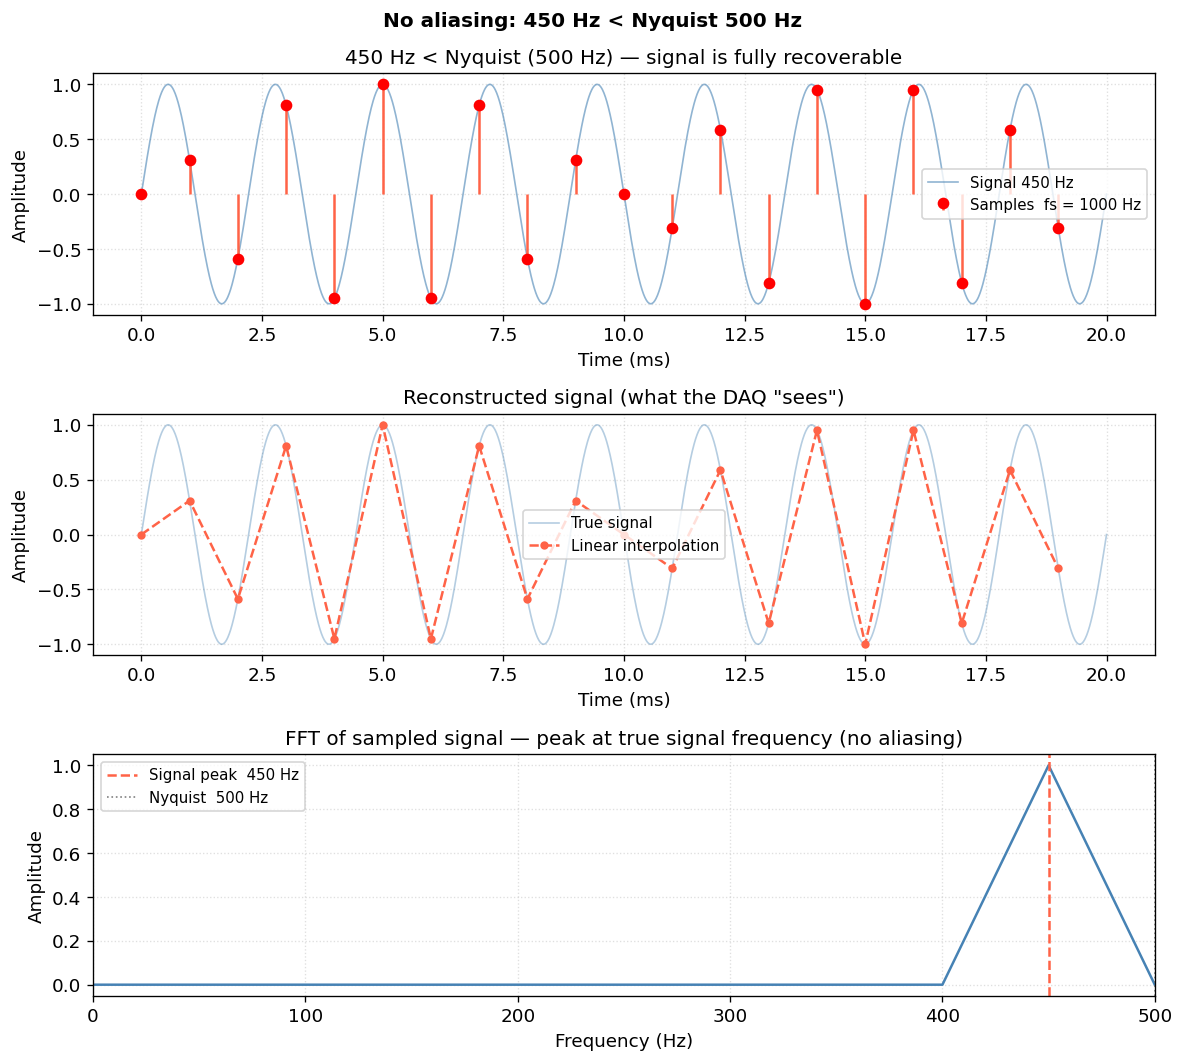

In [2]:
# Aliasing demo — no aliasing (signal below Nyquist)
f_sig = 450.0; f_s = 1000.0
nyquist = f_s / 2
t_c = np.linspace(0, 0.02, 2000)
t_s = np.arange(0, 0.02, 1/f_s)
y_c = np.sin(2*np.pi*f_sig*t_c)
y_s = np.sin(2*np.pi*f_sig*t_s)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=False)

# Top: true signal + sample dots
axes[0].plot(t_c*1000, y_c, 'steelblue', lw=1, alpha=0.6, label=f'Signal {f_sig:.0f} Hz')
axes[0].stem(t_s*1000, y_s, linefmt='tomato', markerfmt='ro', basefmt=' ',
             label=f'Samples  fs = {f_s:.0f} Hz')
axes[0].set_ylabel('Amplitude')
axes[0].legend(fontsize=9); axes[0].grid(True, linestyle=':', alpha=0.4)
axes[0].set_title(f'{f_sig:.0f} Hz < Nyquist ({nyquist:.0f} Hz) — signal is fully recoverable')
axes[0].set_xlabel('Time (ms)')

# Middle: true signal vs linear interpolation through samples
axes[1].plot(t_c*1000, y_c, 'steelblue', lw=1, alpha=0.4, label='True signal')
axes[1].plot(t_s*1000, y_s, color='tomato', lw=1.5, linestyle='--', marker='o',
             markersize=4, label='Linear interpolation')
axes[1].set_xlabel('Time (ms)'); axes[1].set_ylabel('Amplitude')
axes[1].legend(fontsize=9); axes[1].grid(True, linestyle=':', alpha=0.4)
axes[1].set_title('Reconstructed signal (what the DAQ "sees")')

# Bottom: FFT of the sampled signal
N = len(y_s)
fft_amp   = np.abs(np.fft.rfft(y_s)) / N * 2
fft_freqs = np.fft.rfftfreq(N, d=1/f_s)

axes[2].plot(fft_freqs, fft_amp, 'steelblue', lw=1.5)
axes[2].axvline(f_sig, color='tomato', lw=1.5, linestyle='--',
                label=f'Signal peak  {f_sig:.0f} Hz')
axes[2].axvline(nyquist, color='grey', lw=1, linestyle=':',
                label=f'Nyquist  {nyquist:.0f} Hz')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Amplitude')
axes[2].set_title('FFT of sampled signal — peak at true signal frequency (no aliasing)')
axes[2].legend(fontsize=9); axes[2].grid(True, linestyle=':', alpha=0.4)
axes[2].set_xlim(0, nyquist)

fig.suptitle(f'No aliasing: {f_sig:.0f} Hz < Nyquist {nyquist:.0f} Hz',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig31_nb1_aliasing_below_nyquist.png', bbox_inches='tight', dpi=300)
plt.show()


### Example 2 — Signal Above Nyquist (Aliasing)

The signal frequency (850 Hz) exceeds the Nyquist limit (500 Hz) by 350 Hz. The samples are indistinguishable from a 150 Hz tone — the alias frequency $|850 - 1000| = 150$ Hz. The FFT confirms the deception: the spectral peak appears at 150 Hz, not at the true 850 Hz. A DAQ with no anti-aliasing filter would report a completely wrong frequency.

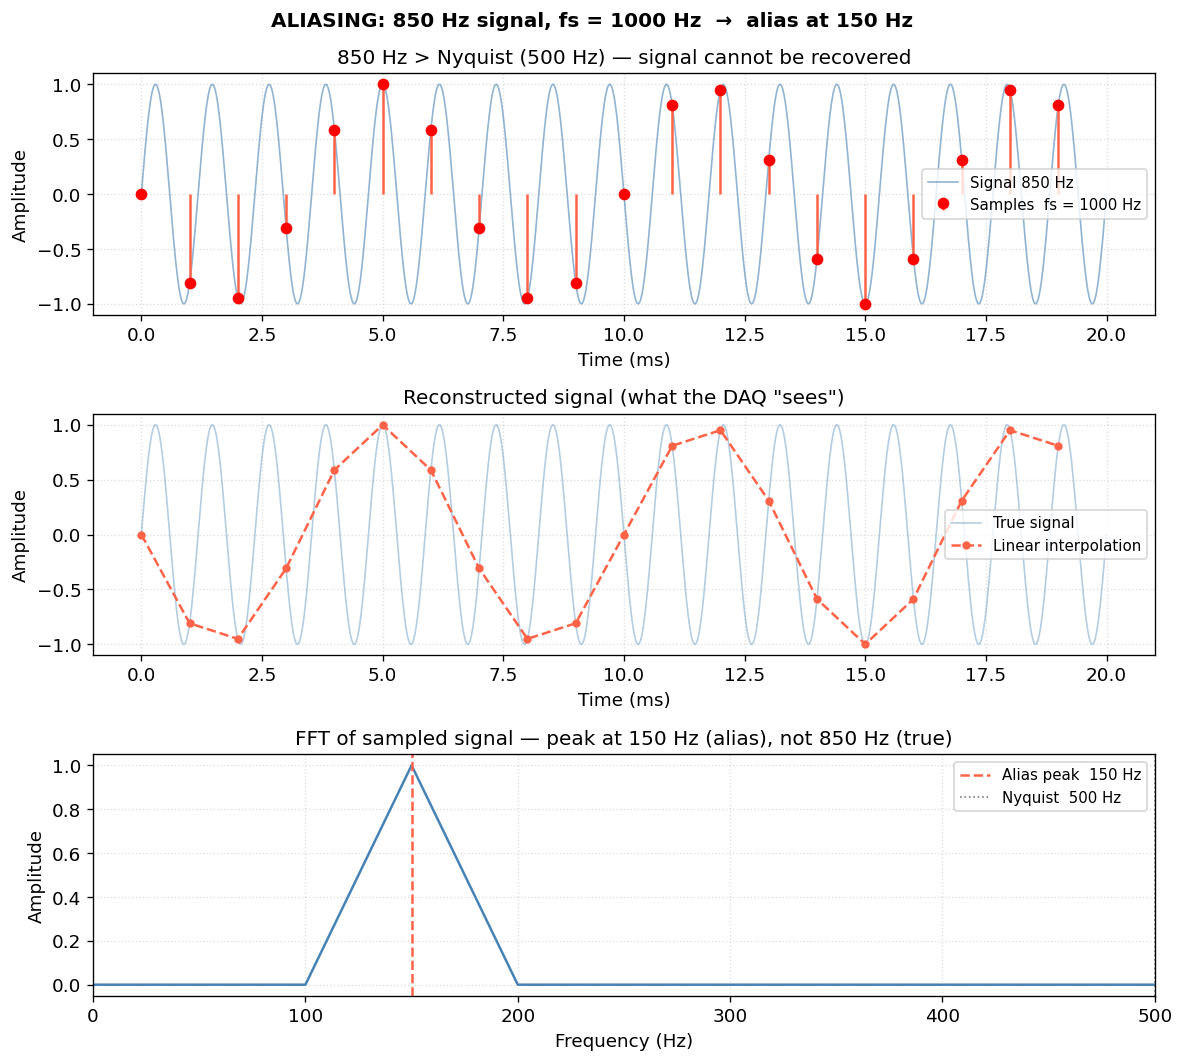

Signal frequency : 850 Hz
Sample rate      : 1000 Hz
Nyquist limit    : 500 Hz
Alias frequency  : |850 - 1000| = 150 Hz

The 850 Hz tone is above Nyquist by 350 Hz.
It folds back and appears as a 150 Hz tone — a measurement error of 700 Hz.


In [3]:
# Aliasing demo — signal ABOVE Nyquist
# 850 Hz signal sampled at 1000 Hz: Nyquist = 500 Hz → alias folds to 150 Hz
f_sig2 = 850.0; f_s2 = 1000.0
nyquist2 = f_s2 / 2
t_c2 = np.linspace(0, 0.02, 4000)
t_s2 = np.arange(0, 0.02, 1/f_s2)
y_c2 = np.sin(2*np.pi*f_sig2*t_c2)
y_s2 = np.sin(2*np.pi*f_sig2*t_s2)
f_alias2 = abs(f_sig2 - f_s2 * round(f_sig2/f_s2))   # = 150 Hz

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=False)

# Top: true signal + sample dots
axes[0].plot(t_c2*1000, y_c2, 'steelblue', lw=1, alpha=0.6, label=f'Signal {f_sig2:.0f} Hz')
axes[0].stem(t_s2*1000, y_s2, linefmt='tomato', markerfmt='ro', basefmt=' ',
             label=f'Samples  fs = {f_s2:.0f} Hz')
axes[0].set_ylabel('Amplitude')
axes[0].legend(fontsize=9); axes[0].grid(True, linestyle=':', alpha=0.4)
axes[0].set_title(f'{f_sig2:.0f} Hz > Nyquist ({nyquist2:.0f} Hz) — signal cannot be recovered')
axes[0].set_xlabel('Time (ms)')

# Middle: true signal vs linear interpolation through samples
axes[1].plot(t_c2*1000, y_c2, 'steelblue', lw=1, alpha=0.4, label='True signal')
axes[1].plot(t_s2*1000, y_s2, color='tomato', lw=1.5, linestyle='--', marker='o',
             markersize=4, label='Linear interpolation')
axes[1].set_xlabel('Time (ms)'); axes[1].set_ylabel('Amplitude')
axes[1].legend(fontsize=9); axes[1].grid(True, linestyle=':', alpha=0.4)
axes[1].set_title('Reconstructed signal (what the DAQ "sees")')

# Bottom: FFT of the sampled signal
N2 = len(y_s2)
fft_amp2   = np.abs(np.fft.rfft(y_s2)) / N2 * 2
fft_freqs2 = np.fft.rfftfreq(N2, d=1/f_s2)

axes[2].plot(fft_freqs2, fft_amp2, 'steelblue', lw=1.5)
axes[2].axvline(f_alias2, color='tomato', lw=1.5, linestyle='--',
                label=f'Alias peak  {f_alias2:.0f} Hz')
axes[2].axvline(nyquist2, color='grey', lw=1, linestyle=':',
                label=f'Nyquist  {nyquist2:.0f} Hz')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Amplitude')
axes[2].set_title(f'FFT of sampled signal — peak at {f_alias2:.0f} Hz (alias), not {f_sig2:.0f} Hz (true)')
axes[2].legend(fontsize=9); axes[2].grid(True, linestyle=':', alpha=0.4)
axes[2].set_xlim(0, nyquist2)

fig.suptitle(f'ALIASING: {f_sig2:.0f} Hz signal, fs = {f_s2:.0f} Hz  →  alias at {f_alias2:.0f} Hz',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig31_nb1_aliasing_above_nyquist.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"Signal frequency : {f_sig2:.0f} Hz")
print(f"Sample rate      : {f_s2:.0f} Hz")
print(f"Nyquist limit    : {nyquist2:.0f} Hz")
print(f"Alias frequency  : |{f_sig2:.0f} - {f_s2:.0f}| = {f_alias2:.0f} Hz")
print(f"\nThe {f_sig2:.0f} Hz tone is above Nyquist by {f_sig2-nyquist2:.0f} Hz.")
print(f"It folds back and appears as a {f_alias2:.0f} Hz tone — a measurement error of {f_sig2-f_alias2:.0f} Hz.")


## ADC Resolution, Dynamic Range, and Strain Sensitivity

The **analog-to-digital converter (ADC)** determines how finely the bridge output voltage can be resolved. An $n$-bit ADC divides its input range into $2^n$ discrete counts. Dynamic range in decibels scales linearly with bit depth:

$$\text{DR} = 20 \log_{10}(2^n) \approx 6.02\, n \;\text{dB}$$

The minimum detectable strain follows directly from the LSB voltage and the bridge sensitivity ($V_{out}/V_{exc} = GF \cdot \varepsilon / 4$):

$$\varepsilon_{min} = \frac{4 \cdot \text{LSB}}{V_{exc} \cdot GF}$$

The table below shows how these quantities scale across the five ADC widths most commonly found in strain gage DAQ systems, normalized to 1 V excitation and a ±1 V input range.

In [4]:
V_exc   = 1.0    # excitation voltage (V)
GF      = 2.0    # gage factor
V_range = 2.0    # ADC full-scale range (±1 V)

common = [8, 12, 16, 18, 24]

rows = []
for bits in common:
    counts = 2**bits
    dr_db  = 20 * np.log10(counts)
    lsb_uv = V_range / counts * 1e6
    eps_ue = V_range / counts / (V_exc * GF / 4) * 1e6  # microstrain
    rows.append({"Bits": bits, "Counts": counts, "DR (dB)": dr_db,
                 "LSB @ ±1 V (μV)": lsb_uv, "ε_res (με)": eps_ue})

df = pd.DataFrame(rows).set_index("Bits")

def fmt_counts(x):
    """Format an integer count with thousands separators (e.g. 65,536)."""
    return f"{int(x):,}"

def fmt_num(x):
    """Format a float with a precision suited to its magnitude.

    Large values get thousands separators, mid-range values four decimals,
    and very small values scientific notation, so the table stays readable
    across the ~5-decade span from 8-bit to 24-bit resolution.
    """
    if abs(x) >= 1000:
        return f"{x:,.1f}"
    elif abs(x) >= 0.01:
        return f"{x:.4f}"
    else:
        return f"{x:.3e}"

styled = (
    df.style
    .format({"Counts": fmt_counts,
             "DR (dB)": "{:.1f}",
             "LSB @ ±1 V (μV)": fmt_num,
             "ε_res (με)": fmt_num})
    .set_caption(
        "ADC Resolution: Dynamic Range and Strain Sensitivity<br>"
        "<span style='font-size:11px; font-weight:normal'>"
        "V<sub>exc</sub> = 1 V &nbsp;|&nbsp; GF = 2.0 &nbsp;|&nbsp; ADC range = ±1 V"
        "</span>"
    )
    .set_table_styles([
        {"selector": "caption", "props": [
            ("font-size", "14px"), ("font-weight", "bold"), ("text-align", "left"),
            ("padding-bottom", "10px"), ("caption-side", "top")
        ]},
        {"selector": "thead th", "props": [
            ("background-color", "#4a6278"), ("color", "white"),
            ("padding", "8px 20px"), ("text-align", "center"),
            ("border-bottom", "1px solid #3a5068"), ("white-space", "nowrap")
        ]},
        {"selector": "th.row_heading", "props": [
            ("background-color", "#4a6278"), ("color", "white"),
            ("padding", "8px 16px"), ("text-align", "center")
        ]},
        {"selector": "td", "props": [
            ("padding", "7px 20px"), ("text-align", "right"),
            ("font-family", "monospace"), ("font-size", "13px"),
            ("border-bottom", "1px solid #e0e0e0")
        ]},
        {"selector": "tr:nth-child(even)", "props": [
            ("background-color", "#f4f4f4")
        ]},
        {"selector": "tr:hover", "props": [("background-color", "#fef9e7")]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse"), ("border", "1px solid #ddd"),
            ("min-width", "480px")
        ]},
    ])
)
styled

,Counts,DR (dB),LSB @ ±1 V (μV),ε_res (με)
Bits,,,,
8,256,48.2,"7,812.5","15,625.0"
12,"4,096",72.2,488.2812,976.5625
16,"65,536",96.3,30.5176,61.0352
18,"262,144",108.4,7.6294,15.2588
24,"16,777,216",144.5,0.1192,0.2384


### Strain Resolution and the Cost of Wasted Range

The converter limits above become concrete once a full-scale strain range is chosen. For a system scaled to a fixed full scale $FS$, the strain represented by one count is $FS / 2^{N}$ — so resolution improves exponentially with bit depth.

But bit depth is only half the story. If the signal of interest fills only a *fraction* $f$ of the ADC's input range, it exercises only $f \cdot 2^{N}$ counts and gives up $-\log_2 f$ bits of effective resolution. Filling 10% of range throws away more than three bits — undoing the gap between a 16- and a 20-bit converter. This is why matching conditioner gain to the expected signal matters as much as the converter spec.

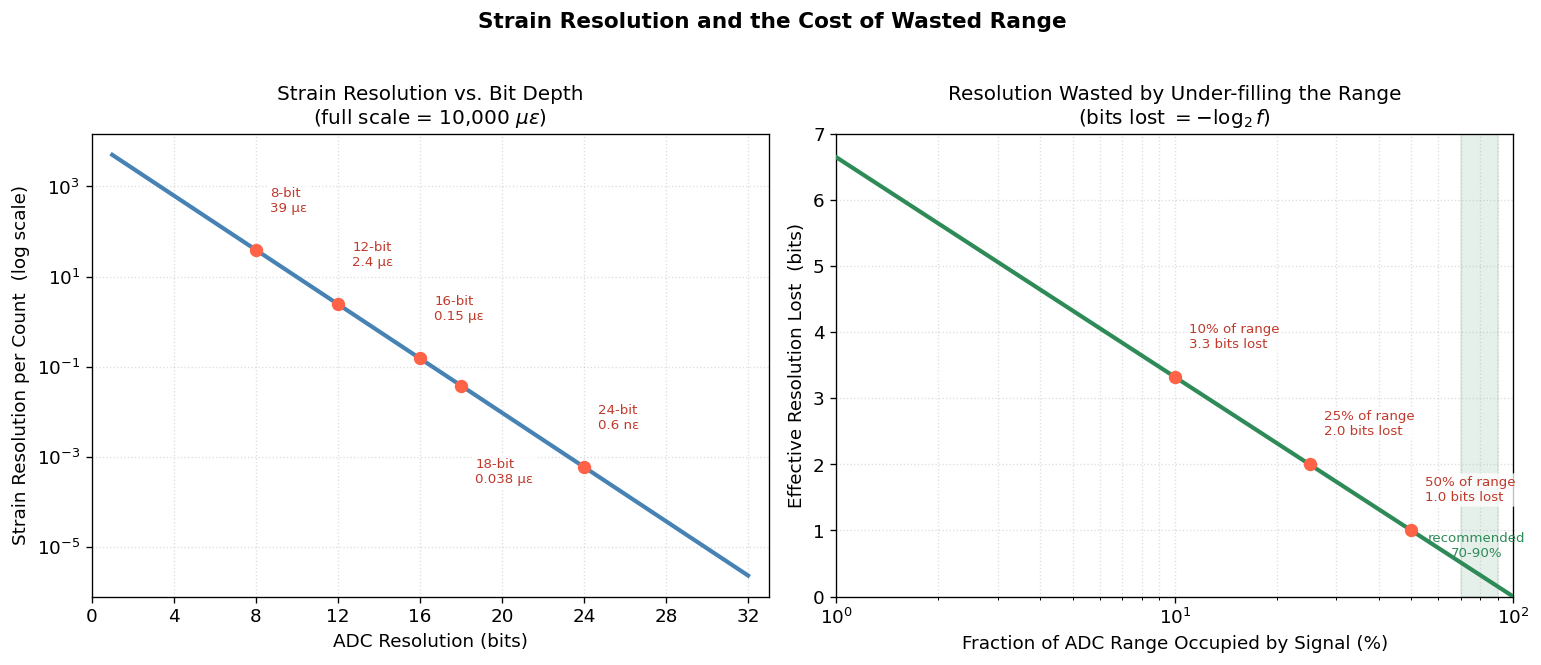

In [5]:
# Strain-specific resolution and the cost of under-filling the ADC range
FS_ue = 10_000.0                 # full-scale strain range (microstrain)
bits  = np.arange(1, 33)
eps_ue = FS_ue / (2.0 ** bits)   # strain per count (microstrain)

marks = [8, 12, 16, 18, 24]

def eps_str(x):
    """Format a per-count strain value in the largest sensible unit (με, nε, or pε)."""
    if x >= 0.01: return f'{x:.2g} με'
    if x >= 1e-5: return f'{x*1e3:.2g} nε'
    return f'{x*1e6:.2g} pε'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.4))

# --- Left: strain resolution per count vs bit depth (log scale) ---
ax1.semilogy(bits, eps_ue, color='steelblue', lw=2.5, zorder=3)
for b in marks:
    e = FS_ue / 2**b
    ax1.plot(b, e, 'o', color='tomato', ms=7, zorder=5)
    # 18-bit sits right next to 16-bit, so its label goes below the line
    # instead of above it, where the two labels would collide.
    below = (b == 18)
    ax1.annotate(f'{b}-bit\n{eps_str(e)}', xy=(b, e),
                 xytext=(b + 0.7, e / 40) if below else (b + 0.7, e * 6),
                 fontsize=8, color='#c0392b', va='top' if below else 'bottom',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.75))
ax1.set_xlabel('ADC Resolution (bits)')
ax1.set_ylabel('Strain Resolution per Count  (log scale)')
ax1.set_title(f'Strain Resolution vs. Bit Depth\n(full scale = {FS_ue:,.0f} ' + '$\\mu\\varepsilon$)')
ax1.grid(True, which='both', linestyle=':', alpha=0.4)
ax1.set_xlim(0, 33); ax1.set_xticks(np.arange(0, 33, 4))

# --- Right: effective bits lost when signal fills only fraction f of range ---
frac = np.logspace(-2, 0, 400)          # 1% .. 100% of full scale
bits_lost = -np.log2(frac)
ax2.semilogx(frac * 100, bits_lost, color='seagreen', lw=2.5, zorder=3)
ax2.axvspan(70, 90, color='seagreen', alpha=0.12, zorder=0)
ax2.text(78, 0.55, 'recommended\n70-90%', fontsize=8, color='seagreen',
         ha='center', va='bottom')
for f_pct, note in [(10, '10%'), (25, '25%'), (50, '50%')]:
    bl = -np.log2(f_pct / 100)
    ax2.plot(f_pct, bl, 'o', color='tomato', ms=7, zorder=5)
    ax2.annotate(f'{note} of range\n{bl:.1f} bits lost', xy=(f_pct, bl),
                 xytext=(f_pct * 1.1, bl + 0.4), fontsize=8, color='#c0392b',
                 va='bottom', bbox=dict(boxstyle='round,pad=0.2', fc='white',
                 ec='none', alpha=0.75))
ax2.set_xlabel('Fraction of ADC Range Occupied by Signal (%)')
ax2.set_ylabel('Effective Resolution Lost  (bits)')
ax2.set_title('Resolution Wasted by Under-filling the Range\n(bits lost $= -\\log_2 f$)')
ax2.grid(True, which='both', linestyle=':', alpha=0.4)
ax2.set_xlim(1, 100); ax2.set_ylim(0, 7)

fig.suptitle('Strain Resolution and the Cost of Wasted Range',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig31_nb1_strain_resolution_range.png', bbox_inches='tight', dpi=300)
plt.show()

### Resolution in ppm and dB vs. Bit Depth

Resolution can be stated independently of any particular signal chain. One least-significant bit is a fixed fraction of full scale, $1/2^{N}$, which is $10^{6}/2^{N}$ **parts per million** of full scale. The same quantity expressed logarithmically is the ideal **dynamic range**, $20\log_{10}(2^{N}) pprox 6.02N$ dB. The two are the same fact in different units: every added bit halves the ppm figure and adds about 6 dB. The plot below traces both from 1 to 32 bits, with the common converter depths marked.

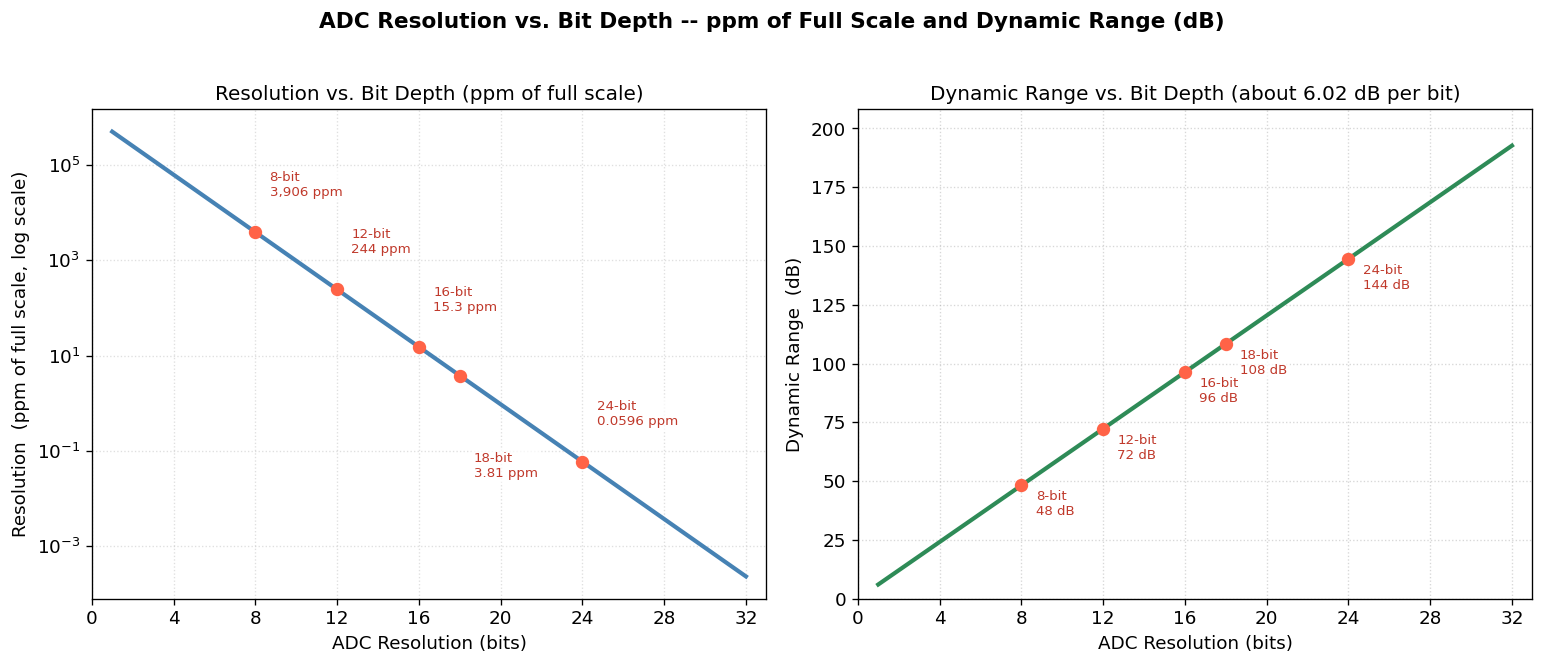

In [6]:
# Resolution (1 LSB as fraction of full scale) vs. bit depth -- two panels: ppm and dB
bits = np.arange(1, 33)
ppm  = 1e6 / (2.0 ** bits)               # 1 LSB as parts-per-million of full scale
db   = 20 * np.log10(2.0 ** bits)        # ideal dynamic range (~6.02 dB per bit)

marks = [8, 12, 16, 18, 24]

def ppm_str(x):
    """Format a ppm value with decimal precision scaled to its magnitude."""
    return f'{x:,.0f}' if x >= 100 else (f'{x:.1f}' if x >= 10 else f'{x:.3g}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.4))

# --- Left: resolution in ppm of full scale (log scale, decreasing) ---
ax1.semilogy(bits, ppm, color='steelblue', lw=2.5, zorder=3)
for b in marks:
    p_b = 1e6 / 2**b
    ax1.plot(b, p_b, 'o', color='tomato', ms=7, zorder=5)
    # 18-bit sits right next to 16-bit, so its label goes below the line
    # instead of above it, where the two labels would collide.
    below = (b == 18)
    ax1.annotate(f'{b}-bit\n{ppm_str(p_b)} ppm', xy=(b, p_b),
                 xytext=(b + 0.7, p_b / 40) if below else (b + 0.7, p_b * 5),
                 fontsize=8, color='#c0392b', va='top' if below else 'bottom',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.75))
ax1.set_xlabel('ADC Resolution (bits)')
ax1.set_ylabel('Resolution  (ppm of full scale, log scale)')
ax1.set_title('Resolution vs. Bit Depth (ppm of full scale)')
ax1.grid(True, which='both', linestyle=':', alpha=0.4)
ax1.set_xlim(0, 33); ax1.set_xticks(np.arange(0, 33, 4))

# --- Right: dynamic range in dB (linear, increasing) ---
ax2.plot(bits, db, color='seagreen', lw=2.5, zorder=3)
for b in marks:
    d_b = 20 * np.log10(2**b)
    ax2.plot(b, d_b, 'o', color='tomato', ms=7, zorder=5)
    ax2.annotate(f'{b}-bit\n{d_b:.0f} dB', xy=(b, d_b), xytext=(b + 0.7, d_b - 14),
                 fontsize=8, color='#c0392b', va='bottom',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.75))
ax2.set_xlabel('ADC Resolution (bits)')
ax2.set_ylabel('Dynamic Range  (dB)')
ax2.set_title('Dynamic Range vs. Bit Depth (about 6.02 dB per bit)')
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.set_xlim(0, 33); ax2.set_xticks(np.arange(0, 33, 4)); ax2.set_ylim(0, db.max() * 1.08)

fig.suptitle('ADC Resolution vs. Bit Depth -- ppm of Full Scale and Dynamic Range (dB)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig31_nb2_resolution_ppm_db.png', bbox_inches='tight', dpi=300)
plt.show()

### Non-simultaneous Sampling: Channel Skew and the Missed Peak

The two measurements most punished by a shared (multiplexed) ADC both stem from the same fact: the channels are *not* sampled at the same instant. The figure below makes both concrete. On the left, a rectangular rosette is read on three consecutive multiplexer channels 1 ms apart while the part vibrates at 60 Hz; the three grid readings the software treats as simultaneous were actually captured at three different phases. On the right, a coupon is ramped to fracture, and the last sample before the part breaks falls short of the true peak by one sampling interval's worth of strain.

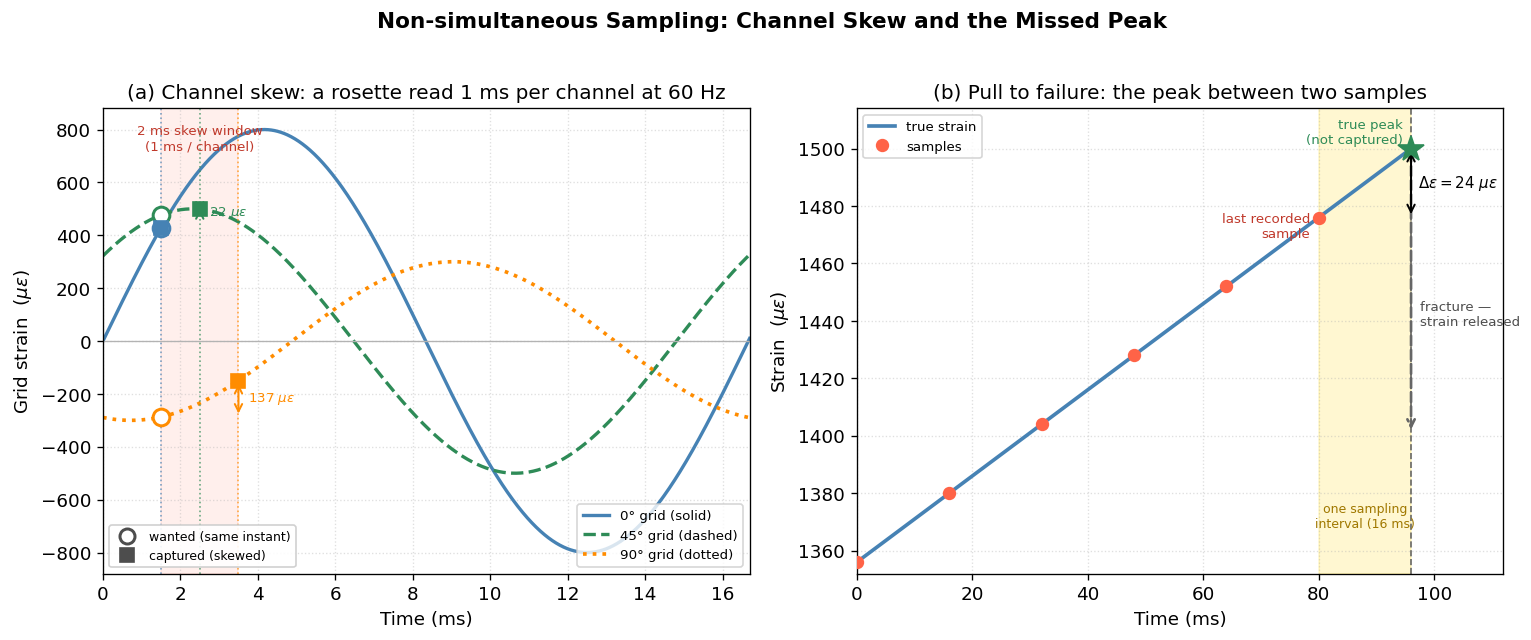

In [7]:
# Non-simultaneous sampling: (a) rosette channel skew, (b) missed peak at fracture
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5.2))

# ---------- Panel (a): channel skew on a rosette ----------
f_hz = 60.0
w = 2 * np.pi * f_hz
t_ms = np.linspace(0, 16.7, 1200)          # one 60 Hz period, in ms

def grid(amp, phase):
    """Strain history of one rosette grid: amp * sin(wt + phase), t in ms."""
    return amp * np.sin(w * t_ms / 1000.0 + phase)

gA, gB, gC = grid(800, 0.0), grid(500, 0.7), grid(-300, 1.3)

# distinct line styles as well as colours, so the three grids read in grayscale
axA.plot(t_ms, gA, color='steelblue', lw=2,  ls='-',  label='0° grid (solid)')
axA.plot(t_ms, gB, color='seagreen',  lw=2,  ls='--', label='45° grid (dashed)')
axA.plot(t_ms, gC, color='darkorange', lw=2.2, ls=':', label='90° grid (dotted)')
axA.axhline(0, color='0.7', lw=0.8)

t0 = 1.5                                    # ms, first channel sampled
samp_t = [t0, t0 + 1.0, t0 + 2.0]           # grids sampled 1 ms apart
curves = [(800, 0.0), (500, 0.7), (-300, 1.3)]
colors = ['steelblue', 'seagreen', 'darkorange']

def val(amp, phase, tt):
    """Grid strain at a single instant tt (ms): amp * sin(w*tt + phase)."""
    return amp * np.sin(w * tt / 1000.0 + phase)

# shade the 2 ms skew window
axA.axvspan(t0, t0 + 2.0, color='tomato', alpha=0.10, zorder=0)
# distinct marker SHAPES so the two cases read in grayscale:
#   open circle  = value wanted (the single instant the reduction assumes)
#   filled square = value actually captured (skewed by the multiplexer)
for (amp, ph), ts, c in zip(curves, samp_t, colors):
    true_v = val(amp, ph, t0)               # value at the intended (simultaneous) instant
    samp_v = val(amp, ph, ts)               # value actually captured, ts late
    axA.plot(t0, true_v, marker='o', mfc='white', mec=c, mew=1.8, ms=10, ls='none', zorder=5)  # wanted
    axA.plot(ts, samp_v, marker='s', color=c, ms=8, ls='none', zorder=6)                        # got
    if abs(ts - t0) > 1e-6:
        axA.annotate('', xy=(ts, samp_v), xytext=(ts, true_v),
                     arrowprops=dict(arrowstyle='<->', color=c, lw=1.2))
        axA.text(ts + 0.25, (true_v + samp_v) / 2,
                 f'{abs(samp_v - true_v):.0f} ' + r'$\mu\varepsilon$',
                 color=c, fontsize=8, va='center')
    axA.axvline(ts, color=c, ls=':', lw=1, alpha=0.7)

# shape legend (shape only, drawn in neutral grey so it reads in print)
shape_handles = [
    Line2D([0], [0], marker='o', mfc='white', mec='0.3', mew=1.8, ms=9, ls='none',
           label='wanted (same instant)'),
    Line2D([0], [0], marker='s', color='0.3', ms=8, ls='none',
           label='captured (skewed)'),
]

axA.text(t0 + 1.0, axA.get_ylim()[1] * 0.93, '2 ms skew window\n(1 ms / channel)',
         ha='center', va='top', fontsize=8, color='#c0392b')
axA.set_xlabel('Time (ms)')
axA.set_ylabel(r'Grid strain  ($\mu\varepsilon$)')
axA.set_title('(a) Channel skew: a rosette read 1 ms per channel at 60 Hz')
grid_legend = axA.legend(loc='lower right', fontsize=8)
axA.add_artist(grid_legend)
axA.legend(handles=shape_handles, loc='lower left', fontsize=7.5, framealpha=0.9)
axA.grid(True, linestyle=':', alpha=0.4)
axA.set_xlim(0, 16.7)

# ---------- Panel (b): missed peak at fracture ----------
r = 1.5            # microstrain per ms  (= 1500 microstrain/s)
dt = 16.0          # ms per-channel sampling interval (62.5 S/s)
t_frac = 96.0      # fracture time (ms); worst case: just before next sample
e0 = 1500.0 - r * t_frac      # base so the true peak is 1500 microstrain

t_ramp = np.linspace(0, t_frac, 400)
axB.plot(t_ramp, e0 + r * t_ramp, color='steelblue', lw=2.2, zorder=3, label='true strain')

# samples that actually get taken (strictly before fracture)
s_t = np.arange(0, t_frac, dt)
s_t = s_t[s_t < t_frac]
axB.plot(s_t, e0 + r * s_t, 'o', color='tomato', ms=7, zorder=5, label='samples')

last_t = s_t[-1]
last_v = e0 + r * last_t
peak_v = e0 + r * t_frac

# fracture: instantaneous release
axB.plot([t_frac, t_frac], [peak_v, peak_v], ' ')
axB.annotate('', xy=(t_frac, e0 + r * 30), xytext=(t_frac, peak_v),
             arrowprops=dict(arrowstyle='->', color='0.4', lw=1.6, ls='--'))
axB.axvline(t_frac, color='0.4', ls='--', lw=1)
axB.text(t_frac + 1.5, e0 + r * 55, 'fracture —\nstrain released', fontsize=8, color='0.3')

# true peak (missed) and last recorded sample
axB.plot(t_frac, peak_v, '*', color='seagreen', ms=16, zorder=6)
axB.text(t_frac - 1.5, peak_v + 2, 'true peak\n(not captured)', ha='right',
         fontsize=8, color='seagreen')
axB.text(last_t - 1.5, last_v - 7, 'last recorded\nsample', ha='right',
         fontsize=8, color='#c0392b')

# one sampling interval of uncertainty
axB.axvspan(last_t, t_frac, color='gold', alpha=0.18, zorder=0)
axB.text((last_t + t_frac) / 2, e0 + r * 8, 'one sampling\ninterval (16 ms)',
         ha='center', fontsize=7.5, color='#a07800')
# delta-epsilon bracket
axB.annotate('', xy=(t_frac, peak_v), xytext=(t_frac, last_v),
             arrowprops=dict(arrowstyle='<->', color='black', lw=1.2))
axB.text(t_frac + 1.2, (last_v + peak_v) / 2,
         rf'$\Delta\varepsilon = {r * (t_frac - last_t):.0f}\ \mu\varepsilon$',
         fontsize=9, va='center')

axB.set_xlabel('Time (ms)')
axB.set_ylabel(r'Strain  ($\mu\varepsilon$)')
axB.set_title('(b) Pull to failure: the peak between two samples')
axB.legend(loc='upper left', fontsize=8)
axB.grid(True, linestyle=':', alpha=0.4)
axB.set_xlim(0, 112)
axB.set_ylim(e0 - 4, peak_v + 14)

fig.suptitle('Non-simultaneous Sampling: Channel Skew and the Missed Peak',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig31_nb3_skew_and_peak.png', bbox_inches='tight', dpi=300)
plt.show()

### Clipping and the Harmonics It Injects

A signal that exceeds the input range is *clipped*: its peaks are flattened at the rail. In the time domain a lightly clipped sinusoid can still look almost sinusoidal, and its mean, RMS, and even its dominant frequency may look reasonable. The damage shows up in the spectrum. Flattening the peaks of a sine wave drives it toward a square wave, and the harmonics that appear are entirely an artifact of the clipping — they are not present in the strain — yet they are indistinguishable, after the fact, from real high-frequency content.

The figure shows three cases. A clean sinusoid (top) has a spectrum that is a single line at the fundamental. A **symmetrically** clipped sinusoid (middle) — flattened equally top and bottom — preserves half-wave symmetry, so it generates only **odd** harmonics (3f, 5f, 7f, ...). An **asymmetrically** clipped sinusoid (bottom) — flattened unequally, or clipped about a signal with an offset — breaks that symmetry, so it generates **even** harmonics (2f, 4f, 6f, ...) as well, and shifts the mean, adding a **DC** error. Both kinds of clipping corrupt the spectrum; asymmetric clipping corrupts the zero level too.

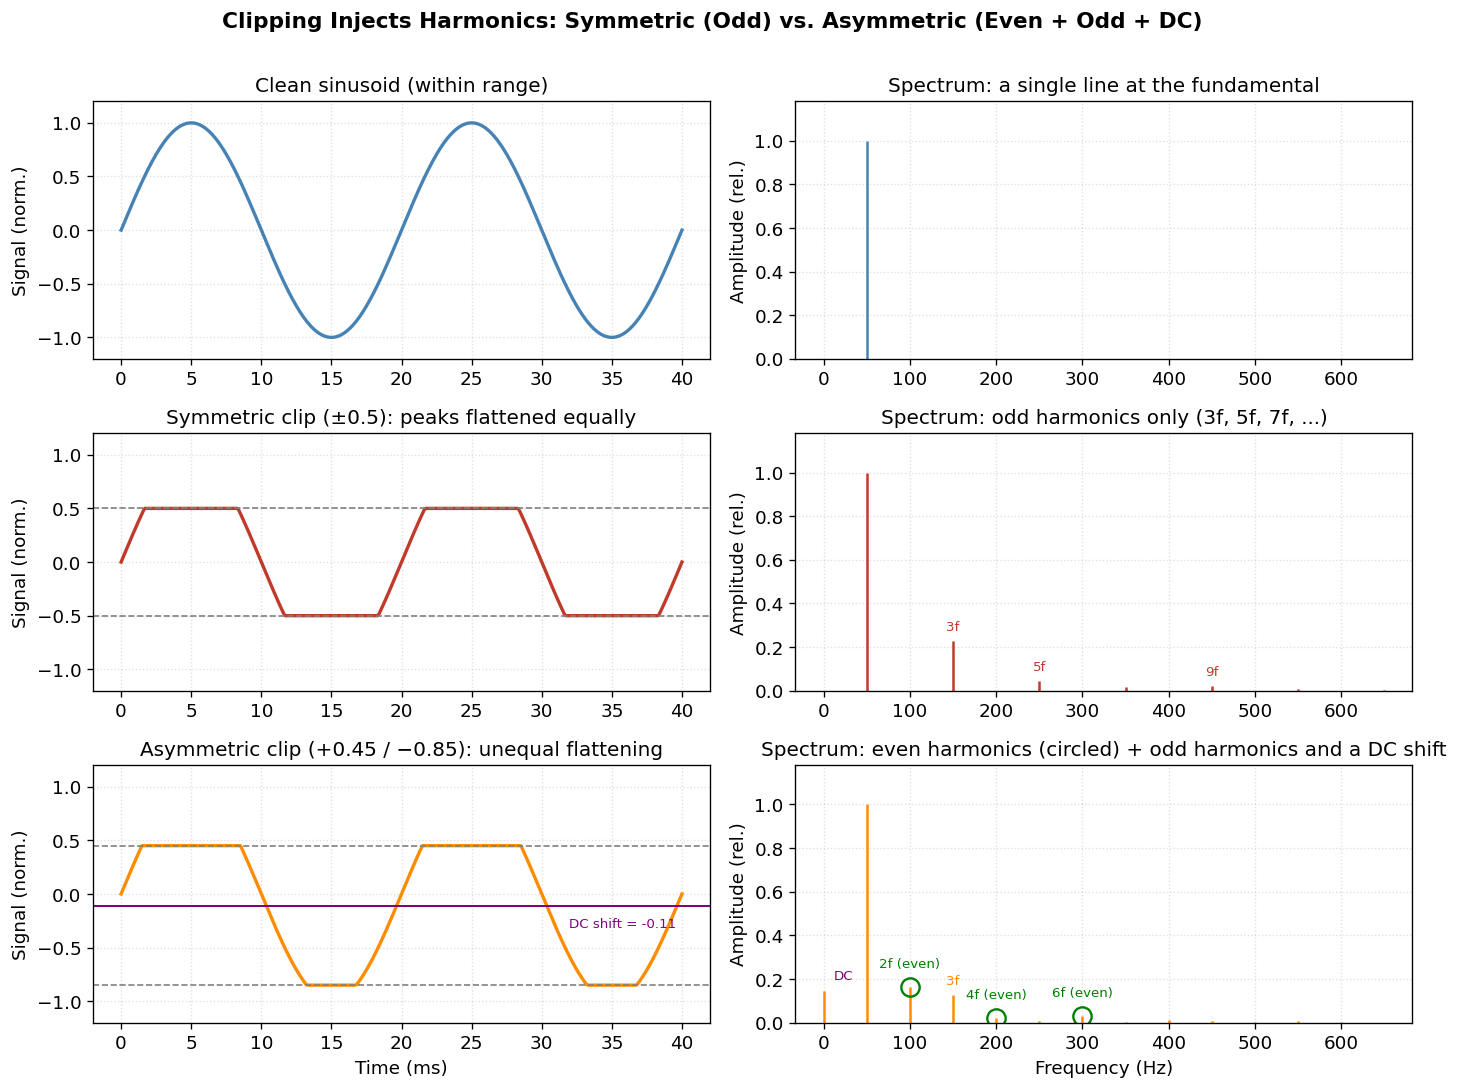

In [8]:
# Clipping injects harmonics: clean vs. symmetric clip (odd) vs. asymmetric clip (even+odd+DC)
f0 = 50.0          # signal frequency (Hz)
fs = 10000.0       # sample rate (Hz)
N  = int(fs)       # 1 s -> coherent sampling, f0 lands exactly on a bin (no leakage)
t  = np.arange(N) / fs

clean = np.sin(2 * np.pi * f0 * t)
sym   = np.clip(clean, -0.5, 0.5)        # symmetric clip  -> odd harmonics only
asym  = np.clip(clean, -0.85, 0.45)      # asymmetric clip -> even + odd harmonics + DC shift

def spectrum(y):
    """Single-sided amplitude spectrum of y, normalized to the fundamental at f0.

    Returns (freqs, amplitudes) where amplitudes are scaled so the bin nearest
    f0 equals 1.0, making the harmonic content of each waveform directly
    comparable. The DC bin is corrected for the single-sided doubling.
    """
    Y = np.abs(np.fft.rfft(y)) * 2.0 / N
    Y[0] /= 2.0                          # DC term is not doubled
    f = np.fft.rfftfreq(N, 1.0 / fs)
    i0 = np.argmin(np.abs(f - f0))
    return f, Y / Y[i0]                  # normalize to the fundamental

f_c, Y_c = spectrum(clean)
f_s, Y_s = spectrum(sym)
f_a, Y_a = spectrum(asym)

fig, ax = plt.subplots(3, 2, figsize=(12, 9))
tmax = 2.0 / f0 * 1000.0                 # show 2 cycles, in ms
m = t * 1000.0 <= tmax
fmax = 650
sel = f_c <= fmax

# ---- row 0: clean ----
ax[0, 0].plot(t[m] * 1000, clean[m], color='steelblue', lw=2)
ax[0, 0].set_title('Clean sinusoid (within range)')
ax[0, 0].set_ylabel('Signal (norm.)'); ax[0, 0].set_ylim(-1.2, 1.2)
ax[0, 1].stem(f_c[sel], Y_c[sel], linefmt='steelblue', markerfmt=' ', basefmt=' ')
ax[0, 1].set_title('Spectrum: a single line at the fundamental')
ax[0, 1].set_ylabel('Amplitude (rel.)'); ax[0, 1].set_ylim(0, 1.18)

# ---- row 1: symmetric clip -> odd harmonics ----
ax[1, 0].plot(t[m] * 1000, sym[m], color='#c0392b', lw=2)
ax[1, 0].axhline(0.5, color='0.5', ls='--', lw=1)
ax[1, 0].axhline(-0.5, color='0.5', ls='--', lw=1)
ax[1, 0].set_title('Symmetric clip (±0.5): peaks flattened equally')
ax[1, 0].set_ylabel('Signal (norm.)'); ax[1, 0].set_ylim(-1.2, 1.2)
ax[1, 1].stem(f_s[sel], Y_s[sel], linefmt='#c0392b', markerfmt=' ', basefmt=' ')
for n in (3, 5, 7, 9, 11):
    fh = n * f0
    if fh <= fmax:
        amp = Y_s[np.argmin(np.abs(f_s - fh))]
        if amp > 0.02:
            ax[1, 1].annotate(f'{n}f', xy=(fh, amp), xytext=(fh, amp + 0.05),
                              ha='center', fontsize=8, color='#c0392b')
ax[1, 1].set_title('Spectrum: odd harmonics only (3f, 5f, 7f, ...)')
ax[1, 1].set_ylabel('Amplitude (rel.)'); ax[1, 1].set_ylim(0, 1.18)

# ---- row 2: asymmetric clip -> even + odd harmonics + DC ----
dc = asym.mean()
ax[2, 0].plot(t[m] * 1000, asym[m], color='darkorange', lw=2)
ax[2, 0].axhline(0.45, color='0.5', ls='--', lw=1)
ax[2, 0].axhline(-0.85, color='0.5', ls='--', lw=1)
ax[2, 0].axhline(dc, color='purple', ls='-', lw=1.2)
ax[2, 0].text(tmax * 0.99, dc - 0.2, f'DC shift = {dc:+.2f}', ha='right',
              fontsize=8, color='purple')
ax[2, 0].set_title('Asymmetric clip (+0.45 / −0.85): unequal flattening')
ax[2, 0].set_xlabel('Time (ms)'); ax[2, 0].set_ylabel('Signal (norm.)')
ax[2, 0].set_ylim(-1.2, 1.2)
ax[2, 1].stem(f_a[sel], Y_a[sel], linefmt='darkorange', markerfmt=' ', basefmt=' ')
ax[2, 1].annotate('DC', xy=(0, Y_a[0]), xytext=(12, Y_a[0] + 0.05),
                  fontsize=8, color='purple')
for n in (2, 3, 4, 5, 6, 7):
    fh = n * f0
    if fh <= fmax:
        amp = Y_a[np.argmin(np.abs(f_a - fh))]
        even = n % 2 == 0
        # every even harmonic is marked, however small; odd ones only if visible
        if amp > (0.002 if even else 0.02):
            col = 'green' if even else 'darkorange'
            # The even harmonics are the diagnostic ones, so they get a circle
            # as well as a colour: the softcover edition prints in gray, where
            # green and orange are the same ink.
            if even:
                ax[2, 1].plot(fh, amp, marker='o', ms=11, mfc='none', mec=col,
                              mew=1.4)
            ax[2, 1].annotate(f'{n}f' + (' (even)' if even else ''),
                              xy=(fh, amp),
                              xytext=(fh, amp + (0.09 if even else 0.05)),
                              ha='center', fontsize=8, color=col)
ax[2, 1].set_title('Spectrum: even harmonics (circled) + odd harmonics and a DC shift')
ax[2, 1].set_xlabel('Frequency (Hz)'); ax[2, 1].set_ylabel('Amplitude (rel.)')
ax[2, 1].set_ylim(0, 1.18)

for a in ax.flat:
    a.grid(True, linestyle=':', alpha=0.4)

fig.suptitle('Clipping Injects Harmonics: Symmetric (Odd) vs. Asymmetric (Even + Odd + DC)',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig31_nb4_clipping_spectrum.png', bbox_inches='tight', dpi=300)
plt.show()

## Where to take this next

These demonstrations use bare tones and ideal converters so each effect stands alone. The next step in every case is to make them more like a real measurement chain:

- **Add a proper anti-aliasing filter.** The aliasing demo samples a bare 850 Hz tone with nothing between it and the ADC. Insert a low-pass filter (`scipy.signal.butter` or `bessel`) ahead of the sampler, set its cutoff below the 500 Hz Nyquist limit, and confirm the 150 Hz alias vanishes from the FFT — then compare the passband ripple and near-cutoff phase distortion of Butterworth vs. Bessel designs. This is the "not optional" filter the chapter insists on.
- **Replace linear interpolation with sinc (Whittaker–Shannon) reconstruction.** The middle panels of the aliasing figures connect the samples with straight lines. Implement ideal band-limited reconstruction and show that the 450 Hz signal (below Nyquist) is recovered essentially exactly, while the 850 Hz alias is not — driving home that reconstruction cannot undo aliasing once it has happened.
- **Model ENOB, not just ideal bits.** Add Gaussian input noise and a real quantizer to the ADC resolution table, estimate the resulting SNR, and invert the chapter's ENOB relation, Eq. (31.1), $\text{ENOB} = (\text{SNR} - 1.76)/6.02$, to report the *effective* number of bits. You will see why a 24-bit converter rarely delivers 24 usable bits at a strain channel's bandwidth — exactly the gap between the ideal curves here and the noise-limited floor the chapter warns about.